In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
#import seaborn as sns
import cv2
import os
from tqdm import tqdm

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Flatten, Conv2D, MaxPool2D,
    BatchNormalization, AveragePooling2D, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import DenseNet121


In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = (64, 64)
BATCH_SIZE = 32

# 訓練資料生成器，已包含增強
train_datagen = ImageDataGenerator(rescale=1./255)

# 驗證與測試資料生成器，只做 rescale，不做增強
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_dir = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\train"
val_dir = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\val"
test_dir = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\test"

train_set = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_set = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_set = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=1,
    class_mode='categorical',
    shuffle=False
)

# 下面可接你的模型定義、編譯與訓練程式碼


Found 121062 images belonging to 9 classes.
Found 25942 images belonging to 9 classes.
Found 25946 images belonging to 9 classes.


Class Weights (by defect type):
----------------------------------------
Center       (class 0): weight = 4.476
Donut        (class 1): weight = 34.668
Edge-loc     (class 2): weight = 3.704
Edge-ring    (class 3): weight = 1.985
Loc          (class 4): weight = 5.348
Near-Full    (class 5): weight = 129.340
None         (class 6): weight = 0.130
Random       (class 7): weight = 22.197
Scratch      (class 8): weight = 16.109


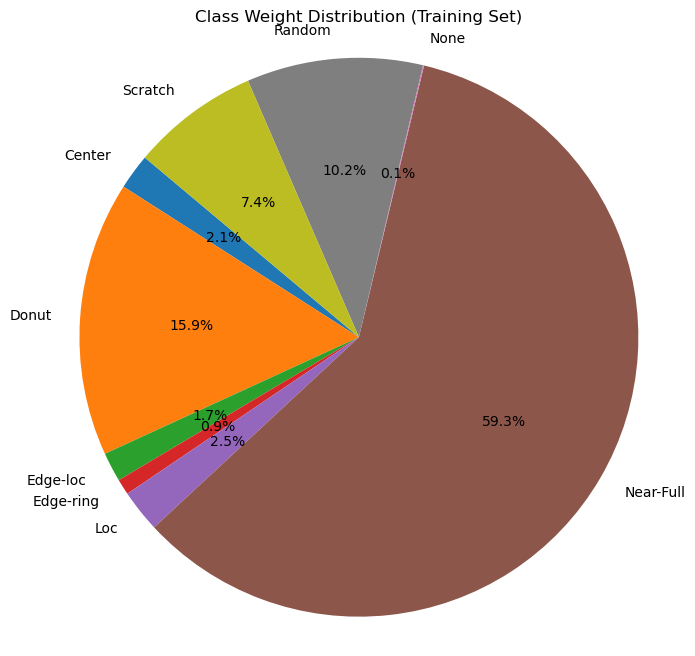

In [3]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import matplotlib.pyplot as plt

# ======================
# 1. 取得 labels（數字）
# ======================
labels = train_set.classes

# ======================
# 2. 計算 class weight
# ======================
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights_array))

# ======================
# 3. 建立 index → class name 對照
# ======================
index_to_class = {v: k for k, v in train_set.class_indices.items()}

print("Class Weights (by defect type):")
print("-" * 40)

for idx, weight in class_weights.items():
    class_name = index_to_class[idx]
    print(f"{class_name:<12} (class {idx}): weight = {weight:.3f}")

# ======================
# 4. 畫圓餅圖
# ======================
labels_name = [index_to_class[i] for i in class_weights.keys()]
weights_val = list(class_weights.values())

plt.figure(figsize=(8, 8))
plt.pie(
    weights_val,
    labels=labels_name,
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Class Weight Distribution (Training Set)")
plt.axis('equal')
plt.show()


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(64,64,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(train_set.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint('best_weight_model.h5', monitor='val_loss', save_best_only=True)

history = model.fit(
    train_set,
    validation_data=val_set,
    epochs=5,
    callbacks=[early_stop, checkpoint, reduce_lr],
    class_weight=class_weights   # ✅ 加這一行
)


Epoch 1/5
3784/3784 [==============================] - 425s 112ms/step - loss: 2.7625 - accuracy: 0.2254 - val_loss: 1.4283 - val_accuracy: 0.8331 - lr: 0.0010
Epoch 2/5
   1/3784 [..............................] - ETA: 8:01 - loss: 1.4144 - accuracy: 0.4688

d:\anaconda\lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


3784/3784 [==============================] - 409s 108ms/step - loss: 2.0466 - accuracy: 0.1239 - val_loss: 1.7881 - val_accuracy: 0.0668 - lr: 0.0010
Epoch 3/5
3784/3784 [==============================] - 402s 106ms/step - loss: 2.0603 - accuracy: 0.0948 - val_loss: 1.6255 - val_accuracy: 0.0699 - lr: 0.0010
Epoch 4/5
3784/3784 [==============================] - ETA: 0s - loss: 2.0425 - accuracy: 0.1306
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
3784/3784 [==============================] - 403s 107ms/step - loss: 2.0425 - accuracy: 0.1306 - val_loss: 1.7306 - val_accuracy: 0.7554 - lr: 0.0010
Epoch 5/5
3784/3784 [==============================] - 734s 194ms/step - loss: 1.9728 - accuracy: 0.2744 - val_loss: 1.4739 - val_accuracy: 0.8393 - lr: 5.0000e-04


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
